# ABMIL example

This notebook demonstrates a quick end-to-end CCDI-MCI workflow: (1) retrieve public clinical labels from CCDI cBioPortal, (2) join them to the released embedding manifest, (3) download a small balanced cohort from Hugging Face, and (4) train a attention-based multiple-instance learning (ABMIL) classifier.

The example predicts the cBioPortal sample-level **Cancer Type** attribute: **High-Grade Glioma** versus **Low-Grade Glioma**. It is intended as a usage example, but can be expanded as needed. 

## Setup

`huggingface_hub`, `requests`, `pandas`, `numpy`, `h5py`, `scikit-learn`, `matplotlib`, `torch`, and the dependencies of [MIL-Lab](https://github.com/mahmoodlab/MIL-Lab) are needed.

In [ ]:
%pip install -q huggingface_hub requests pandas numpy h5py scikit-learn matplotlib torch


[notice] A new release of pip is available: 23.2.1 -> 26.2.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [ ]:
from copy import deepcopy
from pathlib import Path
import random
import sys

import h5py
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests
import torch
from huggingface_hub import hf_hub_download, snapshot_download
from sklearn.metrics import (
    ConfusionMatrixDisplay, balanced_accuracy_score, f1_score, roc_auc_score,
)
from sklearn.model_selection import train_test_split
from torch import nn
from torch.utils.data import DataLoader, Dataset

DATA_DIR = Path("ccdi_mci_demo_data")
# clone MIL-Lab repo locally
MIL_LAB_DIR = Path("/data/nextgen/keshk/MIL-Lab")
N_PER_CLASS = 100  # Set to None to use every matched patient.

LABEL_TO_ID = {"Low-Grade Glioma": 0, "High-Grade Glioma": 1}
CLASS_NAMES = list(LABEL_TO_ID)
print(CLASS_NAMES)

seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(seed)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using {device}")

['Low-Grade Glioma', 'High-Grade Glioma']
Using cpu


## Retrieve and join the clinical and imaging metadata

`CANCER_TYPE` is a sample-level clinical attribute in this study. The returned `patientId` joins to `patient_id` in the embedding release manifest. Other clinical attributes area available on cbioportal including the methylation class

In [6]:
manifest_path = hf_hub_download(
    repo_id="CBIIT-CGBB/CCDI-MCI",
    repo_type="dataset",
    filename="metadata/slide_manifest.csv",
    local_dir=DATA_DIR,
)
manifest = pd.read_csv(manifest_path)

response = requests.get(
    "https://cbioportal-api.ccdi.cancer.gov/api/studies/phs002790/clinical-data",
    params={
        "clinicalDataType": "SAMPLE",
    },
    timeout=60,
)
response.raise_for_status()
clinical_records = response.json()

clinical = pd.DataFrame(
    {"patient_id": record["patientId"], "cancer_type": record["value"]}
    for record in clinical_records
    if record.get("clinicalAttributeId") == "CANCER_TYPE"
    and record.get("value") in CLASS_NAMES
).drop_duplicates()

clinical = clinical.drop_duplicates("patient_id")

eligible_slides = manifest.loc[
    manifest["has_conch_v15"].fillna(False), # or switch to uni2h
    ["patient_id", "series_instance_uid"],
].merge(clinical, on="patient_id", how="inner")


patients = (
    eligible_slides[["patient_id", "cancer_type"]]
    .drop_duplicates()
    .sort_values("patient_id")
    .reset_index(drop=True)
)

print(f"Matched patients: {patients['patient_id'].nunique():,}")
display(patients["cancer_type"].value_counts().rename("patients").to_frame())

Matched patients: 1,142


,patients
cancer_type,
Low-Grade Glioma,741
High-Grade Glioma,401


In [8]:
if N_PER_CLASS is None:
    cohort = patients.copy()
else:
    # sample a smaller cohort of patietns for this demo 
    available = patients["cancer_type"].value_counts()
    too_small = available[available < N_PER_CLASS]
    if not too_small.empty:
        raise ValueError(f"Requested {N_PER_CLASS} patients per class, but found {too_small.to_dict()}")
    cohort = (
        patients.groupby("cancer_type", group_keys=False)
        .sample(n=N_PER_CLASS, random_state=seed)
        .sort_values("patient_id")
        .reset_index(drop=True)
    )

cohort["label"] = cohort["cancer_type"].map(LABEL_TO_ID).astype(int)
cohort_slides = eligible_slides.merge(cohort[["patient_id"]], on="patient_id")
print(f"Selected {len(cohort)} patients and {len(cohort_slides)} slides")
display(cohort["cancer_type"].value_counts().rename("patients").to_frame())

Selected 200 patients and 205 slides


,patients
cancer_type,
High-Grade Glioma,100
Low-Grade Glioma,100


## Download the CONCH v1.5 patch embeddings

+ downloads every slide for each selected patient with these selected model. Re-running this cell reuses files already present in `DATA_DIR` so we don't redownload. 
+ this should take around a minute if downloading embeddings for 200 patients

In [9]:
patient_patterns = [
    f"embeddings/conch_v15/{patient_id}/*.h5"
    for patient_id in cohort["patient_id"]
]
snapshot_download(
    repo_id="CBIIT-CGBB/CCDI-MCI",
    repo_type="dataset",
    allow_patterns=patient_patterns,
    local_dir=DATA_DIR,
)

embedding_root = DATA_DIR / "embeddings" / "conch_v15"
patient_files = {
    patient_id: sorted((embedding_root / patient_id).glob("*.h5"))
    for patient_id in cohort["patient_id"]
}

missing = [patient_id for patient_id, paths in patient_files.items() if not paths]
if missing:
    raise FileNotFoundError(f"No downloaded embeddings files for {len(missing)} patients: {missing[:5]}")

cohort["feature_paths"] = cohort["patient_id"].map(patient_files)
print(f"Found {sum(map(len, patient_files.values())):,} downloaded HDF5 files")

Fetching 205 files: 100%|██████████| 205/205 [00:20<00:00, 10.03it/s]

Found 205 downloaded HDF5 files


## Create patient-level splits and the patch bags

+ Splitting happens at the patient level 
+ For patients with multiple slides, all patch embeddings are concatenated into one bag (early fusion). Late fusion ABMIL would be an alternative to try.
+ Training bags are randomly capped at 2,048 instances without replacement. The validation and test bags use every available patch

In [10]:
train_df, remainder_df = train_test_split(
    cohort, test_size=0.30, stratify=cohort["label"], random_state=seed,
)
val_df, test_df = train_test_split(
    remainder_df, test_size=0.50, stratify=remainder_df["label"], random_state=seed,
)
train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

display(pd.DataFrame({
    "train": train_df.cancer_type.value_counts(),
    "validation": val_df.cancer_type.value_counts(),
    "test": test_df.cancer_type.value_counts(),
}).fillna(0).astype(int))

,train,validation,test
cancer_type,,,
Low-Grade Glioma,70,15,15
High-Grade Glioma,70,15,15


In [ ]:
class PatientBagDataset(Dataset):
    """One variable-length bag per patient, concatenating all of their slides."""

    def __init__(self, patient_df, training=False, max_instances=2_048, seed=42):
        self.patient_df = patient_df.reset_index(drop=True)
        self.training = training
        self.max_instances = max_instances
        self.seed = seed
        self.epoch = 0

    def set_epoch(self, epoch):
        self.epoch = int(epoch)

    def __len__(self):
        return len(self.patient_df)

    def __getitem__(self, index):
        row = self.patient_df.iloc[index]
        slide_features = []
        for path in row["feature_paths"]:
            with h5py.File(path, "r") as handle:
                features = handle["features"][:].astype(np.float32) # feature bags can also be cached in memory during dataset construction if enough RAM is available
            if features.ndim != 2 or features.shape[1] != 768:
                raise ValueError(f"Expected (n_patches, 768) features in {path}; got {features.shape}")
            slide_features.append(features)
        if not slide_features:
            raise RuntimeError(f"No readable embeddings for {row['patient_id']}")

        features = np.concatenate(slide_features, axis=0)
        n_total = len(features)
        if self.training and self.max_instances is not None and n_total > self.max_instances:
            rng = np.random.default_rng(self.seed + self.epoch * len(self) + index)
            selected = rng.choice(n_total, self.max_instances, replace=False)
            features = features[selected]

        return (
            torch.from_numpy(features),
            torch.tensor(row["label"], dtype=torch.long),
            {"patient_id": row["patient_id"], "n_total": n_total, "n_used": len(features)},
        )

train_dataset = PatientBagDataset(train_df, training=True, seed=seed)
val_dataset = PatientBagDataset(val_df, seed=seed)
test_dataset = PatientBagDataset(test_df, seed=seed)

train_loader = DataLoader(train_dataset, batch_size=1, shuffle=True, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=1, shuffle=False, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=1, shuffle=False, num_workers=0)

## 5. Create and train MIL-Lab's gated ABMIL model

MIL-Lab's `abmil.base.conch_v15.none` model selects the gated base ABMIL configuration, sets the input width to 768 for CONCH v1.5, and initializes the aggregator with random weights for this two-class task. Only the MIL-Lab aggregator and its classifier are trained; the released CONCH embeddings remain fixed.

In [19]:
if not (MIL_LAB_DIR / "src" / "builder.py").is_file():
    raise FileNotFoundError(
        f"MIL-Lab was not found at {MIL_LAB_DIR}. Update MIL_LAB_DIR to your local checkout."
    )

sys.path.insert(0, str(MIL_LAB_DIR))
from src.builder import create_model

model = create_model(
    "abmil.base.conch_v15.none", # can also try out the pretrained FEATHER extractor with "abmil.base.conch_v15.pc108-24k"
    num_classes=2,
).to(device)
print(model.config)

/data/nextgen/keshk/GBM_MRI/.venv/lib/python3.10/site-packages/torch/jit/_script.py:1491: FutureWarning: `torch.jit.script` is deprecated. Please switch to `torch.compile` or `torch.export`.
  warnings.warn(


ABMILGatedBaseConfig {
  "attn_dim": 384,
  "auto_map": {
    "AutoConfig": "modeling_abmil.ABMILGatedBaseConfig",
    "AutoModel": "modeling_abmil.ABMILModel"
  },
  "dropout": 0.25,
  "embed_dim": 512,
  "gate": true,
  "in_dim": 768,
  "model_type": "abmil",
  "num_classes": 2,
  "num_fc_layers": 1,
  "transformers_version": "5.17.0"
}



/data/nextgen/keshk/MIL-Lab/src/builders/ModelDict.py:193: UserWarning: Pretrained flag is True, but task is set to 'none'. Using random weights
  warnings.warn("Pretrained flag is True, but task is set to 'none'. Using random weights")


In [20]:
@torch.no_grad()
def evaluate(model, loader, loss_fn):
    model.eval()
    losses, labels, predictions, probabilities, patient_ids = [], [], [], [], []
    for features, label, metadata in loader:
        features, label = features.to(device), label.to(device)
        results, _ = model(features, loss_fn=loss_fn, label=label)
        logits = results["logits"]
        losses.append(results["loss"].item())
        probability = torch.softmax(logits, dim=1)
        labels.extend(label.cpu().numpy())
        predictions.extend(logits.argmax(dim=1).cpu().numpy())
        probabilities.extend(probability[:, 1].cpu().numpy())
        patient_ids.extend(metadata["patient_id"])
    return {
        "loss": float(np.mean(losses)),
        "labels": np.asarray(labels),
        "predictions": np.asarray(predictions),
        "probabilities": np.asarray(probabilities),
        "patient_ids": patient_ids,
    }

epoch 01 | train loss 0.2418 | val loss 0.3176
epoch 02 | train loss 0.2117 | val loss 0.4496
epoch 03 | train loss 0.1562 | val loss 0.3069
epoch 04 | train loss 0.1600 | val loss 0.3272
epoch 05 | train loss 0.1479 | val loss 0.2992
epoch 06 | train loss 0.1252 | val loss 0.2988
epoch 07 | train loss 0.1184 | val loss 0.2607
epoch 08 | train loss 0.0965 | val loss 0.4153
epoch 09 | train loss 0.0913 | val loss 0.3391
epoch 10 | train loss 0.0800 | val loss 0.3098
epoch 11 | train loss 0.0476 | val loss 0.2932
epoch 12 | train loss 0.0381 | val loss 0.2956
Early stopping


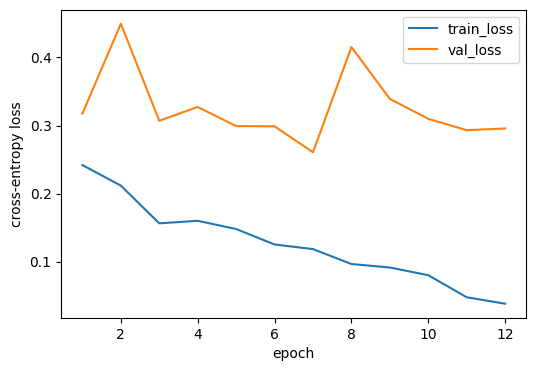

In [23]:
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=5e-5, weight_decay=5e-4)
MAX_EPOCHS, PATIENCE = 30, 5
best_state, best_val_loss, stale_epochs = None, float("inf"), 0
history = []

for epoch in range(MAX_EPOCHS):
    model.train()
    train_dataset.set_epoch(epoch)
    train_losses = []
    for features, label, _ in train_loader:
        features, label = features.to(device), label.to(device)
        optimizer.zero_grad()
        results, _ = model(features, loss_fn=loss_fn, label=label)
        loss = results["loss"]
        loss.backward()
        optimizer.step()
        train_losses.append(loss.item())

    validation = evaluate(model, val_loader, loss_fn)
    train_loss = float(np.mean(train_losses))
    history.append({"epoch": epoch + 1, "train_loss": train_loss, "val_loss": validation["loss"]})
    print(f"epoch {epoch + 1:02d} | train loss {train_loss:.4f} | val loss {validation['loss']:.4f}")

    if validation["loss"] < best_val_loss:
        best_val_loss = validation["loss"]
        best_state = deepcopy(model.state_dict())
        stale_epochs = 0
    else:
        stale_epochs += 1
        if stale_epochs >= PATIENCE:
            print("Early stopping")
            break

model.load_state_dict(best_state)
history_df = pd.DataFrame(history).set_index("epoch")
history_df.plot(y=["train_loss", "val_loss"], ylabel="cross-entropy loss", figsize=(6, 4));

## Eval on the test patients

,ABMIL test metric
balanced_accuracy,0.933333
macro_f1,0.933333
roc_auc,0.991111


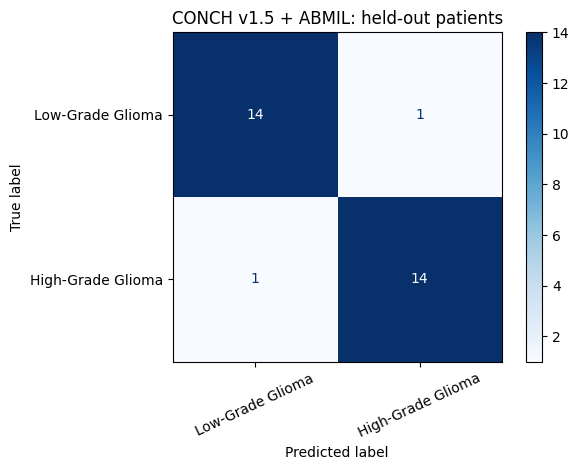

In [24]:
test_result = evaluate(model, test_loader, loss_fn)
test_metrics = {
    "balanced_accuracy": balanced_accuracy_score(test_result["labels"], test_result["predictions"]),
    "macro_f1": f1_score(test_result["labels"], test_result["predictions"], average="macro"),
    "roc_auc": roc_auc_score(test_result["labels"], test_result["probabilities"]),
}
display(pd.Series(test_metrics, name="ABMIL test metric").to_frame())

ConfusionMatrixDisplay.from_predictions(
    test_result["labels"],
    test_result["predictions"],
    display_labels=CLASS_NAMES,
    cmap="Blues",
    xticks_rotation=25,
)
plt.title("CONCH v1.5 + ABMIL: held-out patients")
plt.tight_layout()
plt.show()

## Potential Additions

+ increase `N_PER_CLASS` or set it to `None`
+ repeat patient-level splits across several seeds
+ The released HDF5 files also contain patch coordinates, enabling visualization of ABMIL attention for downstream inspection. 
> Other potential addtions are discussed in our upcoming preprint